#1. Importação das bibliotecas e carregamento dos dados

### 1.1 Bibliotecas

In [2]:
!pip install "numpy<2" "scikit-learn==1.6.1" shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import plotly.express as px
import pandas as pd

# Ferramentas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

###1.2 Carregando os dados

In [4]:
df_tratado = pd.read_csv('https://github.com/JCDIAMANTINO/Datathon-Passos-Magicos-Fase-5/raw/refs/heads/main/Dados_datathon/pede_completo.csv', sep=';', decimal=',')

In [5]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2418 entries, 0 to 2417
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 2418 non-null   int64  
 1   ra                  2418 non-null   object 
 2   nome                2418 non-null   object 
 3   idade               2418 non-null   int64  
 4   genero              2418 non-null   object 
 5   fase                2418 non-null   int64  
 6   turma               2418 non-null   object 
 7   ano_ingresso        2418 non-null   int64  
 8   instituicao_ensino  2418 non-null   object 
 9   inde                2418 non-null   float64
 10  pedra               2418 non-null   object 
 11  fase_ideal          2418 non-null   int64  
 12  defasagem           2418 non-null   float64
 13  iaa                 2418 non-null   float64
 14  ieg                 2418 non-null   float64
 15  ips                 2418 non-null   float64
 16  ida   

#2. Machine Learning

### 2.1 Definindo a variável target (y)

In [6]:
# Definindo a variável alvo (y)
y = df_tratado['risco_defasagem']

# Definindo as variáveis de predição (X)
# Removendo identificadores e colunas que vazam a resposta (que tendenciam o modelo) e desnecessárias
colunas_para_remover = ['ra', 'nome', 'pedra', 'risco_defasagem', 'inde', 'genero', 'turma']
X = df_tratado.drop(columns=colunas_para_remover)

print(f"Tamanho de X (Características): {X.shape}")
print(f"Tamanho de y (Alvo): {y.shape}")

Tamanho de X (Características): (2418, 14)
Tamanho de y (Alvo): (2418,)


### 2.2 Divisão em Treino e Teste

In [7]:
# Divisão em treino (70%) e teste (30%)
# O stratify=y garante que a proporção de alunos em risco seja igual em ambas as partes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Linhas para Treinar o modelo: {X_train.shape[0]}")
print(f"Linhas para Testar o modelo: {X_test.shape[0]}")

Linhas para Treinar o modelo: 1692
Linhas para Testar o modelo: 726


### 2.3 Preparando a Pipeline de Pré-processamento

In [8]:
# Separando quais colunas são números e quais são textos (categorias)
colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

# Criando as transformações
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas), # Padroniza os números
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), colunas_categoricas) # Binariza os textos
    ])

print("Pré-processador criado com sucesso! Ele vai tratar os seguintes textos:", colunas_categoricas)

Pré-processador criado com sucesso! Ele vai tratar os seguintes textos: ['instituicao_ensino']


### 2.4 Criando e Treinando os Modelos

In [9]:
# Criando os Pipelines (Pré-processador + Algoritmo)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Dicionário para organizar a comparação de performance dos modelos
modelos = {
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb,
    'Regressão Logica': pipeline_lr
}

# Treinando e Avaliando cada modelo num loop mágico
print("Iniciando o treinamento dos modelos...\n")

for nome, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    # Calcular as notas (Métricas)
    acuracia = accuracy_score(y_test, y_pred)

    print(f"================ {nome} ================")
    print(f"Acurácia Geral: {acuracia:.4f} ({(acuracia*100):.2f}%)\n")
    print("Relatório de Classificação (Precision, Recall, F1-Score):")
    print(classification_report(y_test, y_pred))
    print("\n")

Iniciando o treinamento dos modelos...

================ Random Forest ================
Acurácia Geral: 0.9449 (94.49%)

Relatório de Classificação (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       445
           1       0.95      0.90      0.93       281

    accuracy                           0.94       726
   macro avg       0.95      0.94      0.94       726
weighted avg       0.95      0.94      0.94       726



================ Gradient Boosting ================
Acurácia Geral: 0.9587 (95.87%)

Relatório de Classificação (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       445
           1       0.96      0.93      0.95       281

    accuracy                           0.96       726
   macro avg       0.96      0.95      0.96       726
weighted avg       0.96      0.96      0.96       726



================ Reg

### 2.5 Prova Visual (Matriz de Confusão)

2.5.1 Regressão lógica (lg)

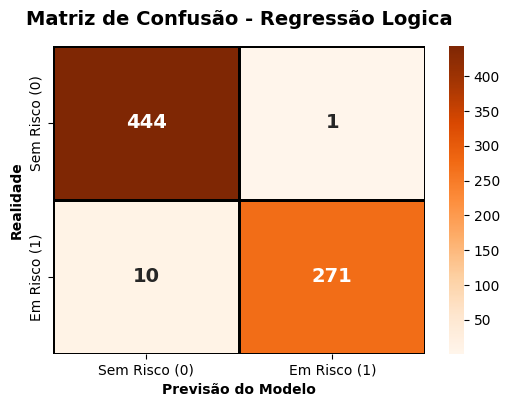

In [10]:
# ==========================================
# 1. MATRIZ DE CONFUSÃO - REGRESSÃO LÓGICA
# ==========================================
modelo_rl = modelos['Regressão Logica']
y_pred_rl = modelo_rl.predict(X_test)
cm_rl = confusion_matrix(y_test, y_pred_rl)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Oranges', linewidths=1, linecolor='black',
            xticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            yticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz de Confusão - Regressão Logica', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold')
plt.ylabel('Realidade', fontweight='bold')
plt.show()

2.5.2 Random Forest (rf)

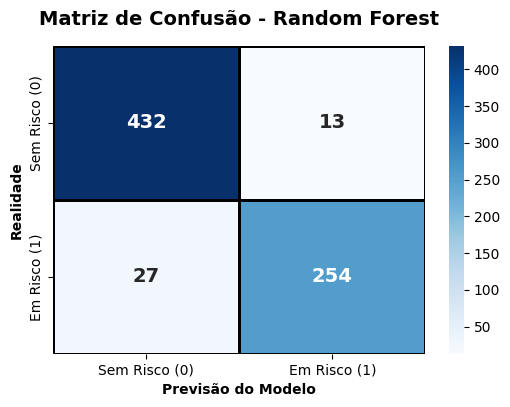

In [11]:
# ==========================================
# 2. MATRIZ DE CONFUSÃO - RANDOM FOREST
# ==========================================
modelo_rf = modelos['Random Forest']
y_pred_rf = modelo_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            yticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz de Confusão - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold')
plt.ylabel('Realidade', fontweight='bold')
plt.show()

2.5.3 Gradinet Boosting (gb)

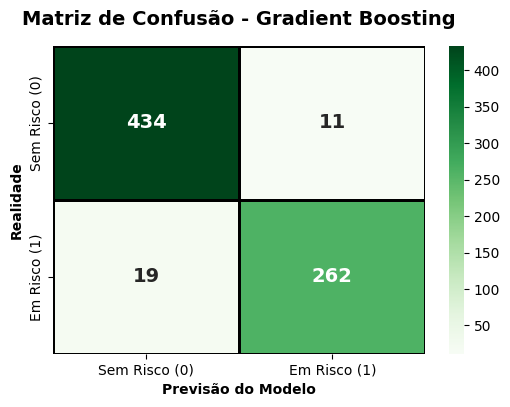

In [12]:
# ==========================================
# 3. MATRIZ DE CONFUSÃO - GRADIENT BOOSTING
# ==========================================
modelo_gb = modelos['Gradient Boosting']
y_pred_gb = modelo_gb.predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', linewidths=1, linecolor='black',
            xticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            yticklabels=['Sem Risco (0)', 'Em Risco (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz de Confusão - Gradient Boosting', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Previsão do Modelo', fontweight='bold')
plt.ylabel('Realidade', fontweight='bold')
plt.show()

# 3. Bloco de Perguntas/ Insights (continuação: 9 a 12)

### Pergunta 9: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

In [13]:
# Atribuindo variável ao modelo vencedor "Gradiente Boosting"(gb)
modelo_final = modelos['Gradient Boosting']

# Acessando o pipeline para obter as importâncias
importancias = modelo_final.named_steps['classifier'].feature_importances_

# Aplicando o transformador para obter os nomes corretos para o SHAP
features = modelo_final.named_steps['preprocessor'].get_feature_names_out(X.columns)

# Criando o DataFrame para o Plotly
df_importancia = pd.DataFrame({
    'Indicador': features,
    'Peso': importancias
})

# Limpando os nomes das colunas (Removendo o prefixo num__ ou cat__ do Pipeline)

df_importancia['Indicador'] = df_importancia['Indicador'].str.replace('num__', '').str.replace('cat__', '')

nomes_amigaveis = {
    'ida': 'Desempenho (IDA)',
    'ieg': 'Engajamento (IEG)',
    'ipv': 'Ponto de Virada (IPV)',
    'iaa': 'Autoavaliação (IAA)',
    'ian': 'Adequação de Nível (IAN)',
    'ips': 'Saúde Psicossocial (IPS)',
    'ipp': 'Psicopedagógico (IPP)',
    'fase': 'Fase no Programa',
    'idade': 'Idade do Aluno',
    'defasagem': 'Defasagem'

}
df_importancia['Indicador'] = df_importancia['Indicador'].map(nomes_amigaveis).fillna(df_importancia['Indicador'])

# Ordenando as posições do gráfico
df_importancia = df_importancia.sort_values(by='Peso', ascending=True)

# Criando o Gráfico de Barras Horizontais Interativo
fig9 = px.bar(df_importancia,
              x='Peso',
              y='Indicador',
              orientation='h',
              title="9. Padrões de Risco: Quais indicadores a IA mais utiliza para prever a defasagem?",
              text_auto='.3f',
              color='Peso',
              color_continuous_scale='Viridis',
              labels={'Peso': 'Grau de Importância (0 a 1)', 'Indicador': 'Fator de Análise'},
              height=600, width=900)

# Ajustes de Layout para o Streamlit
fig9.update_layout(
    coloraxis_showscale=False,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig9.show()

**Insight Analítico:** Observa-se que o algoritmo do modelo de previsão do risco de defasagem não pondera todas as variáveis de forma igual. O Desempenho Acadêmico (IDA) é o fator de maior criticidade (43.30%), seguido pelo Engajamento (IEG), com apenas (18,9%) de influência. Isso significa que, do ponto de vista preditivo, quedas contínuas nestes dois pilares são os maiores alertas de que o aluno pode não atingir os objetivos da sua 'Pedra' atual, exigindo ação imediata da tutoria do programa.

### PERGUNTA 10: (*Efetividade do Programa*) Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [14]:
# Preparando os dados (Agrupando por Pedra, independente do ano)
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_jornada = df_tratado.groupby('pedra')[['inde', 'ida', 'ieg', 'ipv']].mean().reset_index()

# definindo a ordem das variáveis 'jornada'
df_jornada['pedra'] = pd.Categorical(df_jornada['pedra'], categories=ordem_pedras, ordered=True)
df_jornada = df_jornada.sort_values('pedra')

# Transformando para o formato (Melt) compatível para o Plotly
df_plot_jornada = df_jornada.melt(id_vars='pedra', var_name='Indicador', value_name='Media')

# redefinindo os nomes da legenda
nomes_map = {
    'inde': 'Índice Geral (INDE)',
    'ida': 'Desempenho Escolar (IDA)',
    'ieg': 'Engajamento (IEG)',
    'ipv': 'Maturidade/Virada (IPV)'
}
df_plot_jornada['Indicador'] = df_plot_jornada['Indicador'].map(nomes_map)

# Criando o Gráfico de Jornada no Plotly
fig10 = px.line(df_plot_jornada,
                x='pedra',
                y='Media',
                color='Indicador',
                markers=True,
                text=df_plot_jornada['Media'].round(1),
                title="10. Efetividade: A Jornada de Transformação do Aluno (Quartzo a Topázio)",
                labels={'Media': 'Média do Indicador (0 a 10)', 'pedra': 'Estágio do Aluno na ONG'},
                color_discrete_sequence=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'],
                height=850, width=950)

# 4. Ajustes visuais
fig10.update_traces(textposition='top center', line=dict(width=4), marker=dict(size=12))
fig10.update_layout(
    yaxis=dict(range=[0, 11]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(t=100)
)

fig10.show()

**Insight Analítico:** SIM, o gráfico comprova a efetividade do programa. À medida que o aluno progride na sua jornada de transformação (da base 'Quartzo' até ao nível de excelência 'Topázio'), todos os pilares avaliados — Desempenho, Engajamento e Ponto de Virada — apresentam um crescimento expressivo e linear. Isso demonstra que as réguas de progressão não são apenas burocráticas, mas refletem um amadurecimento real, sólido e multidimensional do estudante.

### Pergunta 11 (*Insights*): Quais as fases do programa apresentam maiores indicativos de risco de defasagem (Termômetro de Risco por Fase)?

In [15]:
# Preparando os dados: Média de risco por fase
df_fase_risco = df_tratado.groupby('fase')['risco_defasagem'].mean().reset_index()
df_fase_risco['taxa_risco'] = (df_fase_risco['risco_defasagem'] * 100).round(1)

# Criando o Gráfico com Graduação de Vermelhos
fig11 = px.bar(df_fase_risco,
               x='fase',
               y='taxa_risco',
               color='taxa_risco',
               color_continuous_scale='Reds',
               text_auto='.1f',
               title="11. Insight: Termômetro de Vulnerabilidade (% de Risco por Fase)",
               labels={'taxa_risco': 'Taxa de Risco (%)', 'fase': 'Fase do Programa'},
               height=550, width=900)

# Ajustes de layout para visualizaçãor
fig11.update_layout(
    xaxis=dict(tickmode='linear', title="Fases do Programa"),
    yaxis=dict(range=[0, 100], title="Alunos em Risco (%)"),
    coloraxis_showscale=False,
    template="plotly_white",
    margin=dict(t=100, b=50)
)

# Ajuste das bordas e posição do texto
fig11.update_traces(
    textfont_size=12,
    textposition='outside',
    marker_line_color='rgb(255,255,255)',
    marker_line_width=1.5
)

fig11.show()

**Insight Analítico:** O mapeamento revela um padrão de risco muito específico, concentrado nas fase intermediárias do programa (2 a 5). Enquanto as fases iniciais (Alpha e 1) e finais (6 e 7) apresentam risco de defasagem em patamares inferiores. Logo, as Fases 2 e 3 acendem um alerta ao programa, indicando que a transição pedagógica que ocorre nestas fases exige um plano de contenção robusto e urgente por parte da Associação Passos Mágicos.

### Pergunta 12 (Insights): Existe diferença no resultado médio dos indicadores de desempenho entre alunos de Escolas Públicas e Privadas

In [16]:
# Preparando os dados
df_inst = df_tratado[
    (df_tratado['ano'].astype(str).isin(['2022', '2023', '2024'])) &
    (df_tratado['instituicao_ensino'].isin(['Pública', 'Privada']))
].copy()

# Agrupando e calculando as médias de INDE, IDA e IEG no triênio (2022, 2023 e 2024)
df_comparativo = df_inst.groupby('instituicao_ensino')[['inde', 'ida', 'ieg']].mean().reset_index()

# Transformando para o formato longo (Melt) para o Plotly
df_melted_inst = df_comparativo.melt(id_vars='instituicao_ensino',
                                     var_name='Indicador',
                                     value_name='Media')

# Renomeando variáveis para a legenda
nomes_inst = {
    'inde': 'Resultado Global (INDE)',
    'ida': 'Desempenho Acadêmico (IDA)',
    'ieg': 'Engajamento (IEG)'
}
df_melted_inst['Indicador'] = df_melted_inst['Indicador'].map(nomes_inst)

# Criando o Gráfico de Barras Agrupadas
fig12 = px.bar(df_melted_inst,
               x='instituicao_ensino',
               y='Media',
               color='Indicador',
               barmode='group',
               text_auto='.1f',
               title="11. Insight: O Efeito Equalizador (Escola Pública vs. Privada - 2022 a 2024)",
               labels={'Media': 'Nota Média', 'instituicao_ensino': 'Origem do Aluno'},
               color_discrete_sequence=['#85C1E9', '#82E0AA', '#F9E79F'],
               height=550, width=900)

# Ajustes de layout para o Dashboard
fig12.update_layout(
    yaxis=dict(range=[0, 10.5]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(t=100)
)

fig12.show()

**Insight Analítico:** Os gráfico demonstram que as médias dos indices Globais (INDE), Acadêmico (IDA) e de Engamento (IEG) dos alunos da Rede Privada, dentro do programa, são superiores às dos alunos de Escola Pública. A maior diferença está no IDA (0.9 pontos), já no IEG a diferença na média reduz para (0.5 pontos).

# 4. Tratamentos Finais

In [17]:
# 1. Importando a biblioteca para fazer o download
from google.colab import files

# 2. Selecionando o modelo vencedor (Pipeline completo)
modelo_final = modelos['Gradient Boosting']

# 3. Definindo o nome do arquivo (a extensão .pkl)
nome_do_arquivo = 'modelo_passos_magicos.pkl'

# 4. Salvando o modelo_final
joblib.dump(modelo_final, nome_do_arquivo)
print(f"✅ modelo salvo com sucesso no arquivo: {nome_do_arquivo}")

# 5. Fazendo o download automático do arquivo do modelo '.plk'
files.download(nome_do_arquivo)

✅ modelo salvo com sucesso no arquivo: modelo_passos_magicos.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>